In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pyarrow 
import itertools
from sklearn.linear_model import LinearRegression



In [45]:
import os
print(os.getcwd())

d:\DataScience\churn_prediction_project\notebooks


In [46]:
df = pd.read_csv("../data/Telco_Customer_Churn_Dataset.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [47]:
df.shape

(7043, 21)

In [48]:
#Check columns
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [49]:
"""Cheque datatypes for each columns"""
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [50]:
# Basics estatistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [51]:
#check there is a missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [52]:
# Check the Churn Distribuition
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

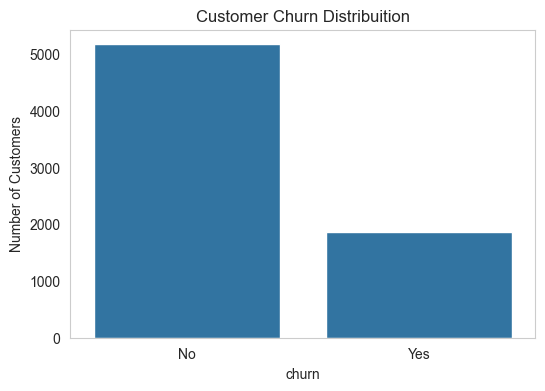

In [53]:
# plot the Churn distribuition
sns.set_style("whitegrid")
plt.figure(figsize=(6,4))
sns.countplot( x = "Churn", data = df)
plt.title("Customer Churn Distribuition")
plt.xlabel("churn")
plt.ylabel("Number of Customers")
plt.grid(axis="y")

plt.show()

In [54]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [55]:
churn_clients = df[df["Churn"] == "Yes"]

In [56]:
churn_clients.shape

(1869, 21)

In [23]:
churn_clients["Contract"].value_counts()

Contract
Month-to-month    1655
One year           166
Two year            48
Name: count, dtype: int64

In [24]:
churn_clients["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             1071
Mailed check                  308
Bank transfer (automatic)     258
Credit card (automatic)       232
Name: count, dtype: int64

In [25]:
churn_clients["TechSupport"].value_counts()

TechSupport
No                     1446
Yes                     310
No internet service     113
Name: count, dtype: int64

In [26]:
churn_clients["Partner"].value_counts()

Partner
No     1200
Yes     669
Name: count, dtype: int64

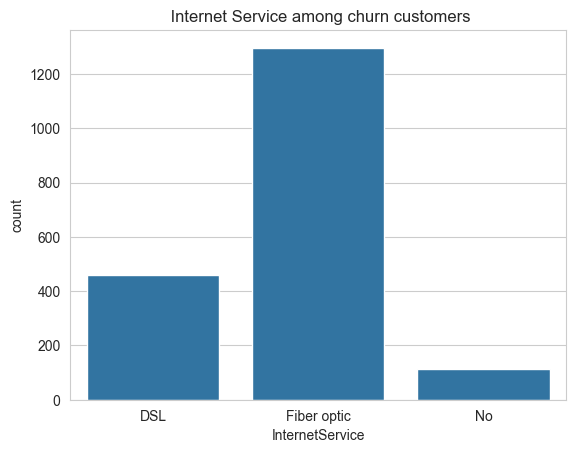

In [27]:
sns.countplot(x = "InternetService", data=churn_clients)
plt.title(" Internet Service among churn customers")
plt.show()

In [18]:
churn_clients["tenure"].mean()

np.float64(17.979133226324237)

In [19]:
churn_clients["MonthlyCharges"].mean()

np.float64(74.44133226324237)

In [28]:
df.groupby("Contract")["Churn"].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

In [29]:
for col in df.columns:
    if df[col].dtype == "object":
        print("\n", col)
        print(df.groupby(col)["Churn"].value_counts(normalize=True))


 customerID
customerID  Churn
0002-ORFBO  No       1.0
0003-MKNFE  No       1.0
0004-TLHLJ  Yes      1.0
0011-IGKFF  Yes      1.0
0013-EXCHZ  Yes      1.0
                    ... 
9987-LUTYD  No       1.0
9992-RRAMN  Yes      1.0
9992-UJOEL  No       1.0
9993-LHIEB  No       1.0
9995-HOTOH  No       1.0
Name: proportion, Length: 7043, dtype: float64

 gender
gender  Churn
Female  No       0.730791
        Yes      0.269209
Male    No       0.738397
        Yes      0.261603
Name: proportion, dtype: float64

 Partner
Partner  Churn
No       No       0.670420
         Yes      0.329580
Yes      No       0.803351
         Yes      0.196649
Name: proportion, dtype: float64

 Dependents
Dependents  Churn
No          No       0.687209
            Yes      0.312791
Yes         No       0.845498
            Yes      0.154502
Name: proportion, dtype: float64

 PhoneService
PhoneService  Churn
No            No       0.750733
              Yes      0.249267
Yes           No       0.732904
      

In [30]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [31]:
def churn_analysis(column):
    result = df.groupby(column)["Churn"].mean().sort_values(ascending = False)
    return result

In [32]:
churn_analysis("Contract")

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

In [33]:
churn_analysis("InternetService")

InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64

In [34]:
for col in df.columns:
    if df[col].dtype == "object":
        print("\n", col)
        print(df.groupby(col)["Churn"].value_counts(normalize=True))


 customerID
customerID  Churn
0002-ORFBO  0        1.0
0003-MKNFE  0        1.0
0004-TLHLJ  1        1.0
0011-IGKFF  1        1.0
0013-EXCHZ  1        1.0
                    ... 
9987-LUTYD  0        1.0
9992-RRAMN  1        1.0
9992-UJOEL  0        1.0
9993-LHIEB  0        1.0
9995-HOTOH  0        1.0
Name: proportion, Length: 7043, dtype: float64

 gender
gender  Churn
Female  0        0.730791
        1        0.269209
Male    0        0.738397
        1        0.261603
Name: proportion, dtype: float64

 Partner
Partner  Churn
No       0        0.670420
         1        0.329580
Yes      0        0.803351
         1        0.196649
Name: proportion, dtype: float64

 Dependents
Dependents  Churn
No          0        0.687209
            1        0.312791
Yes         0        0.845498
            1        0.154502
Name: proportion, dtype: float64

 PhoneService
PhoneService  Churn
No            0        0.750733
              1        0.249267
Yes           0        0.732904
      

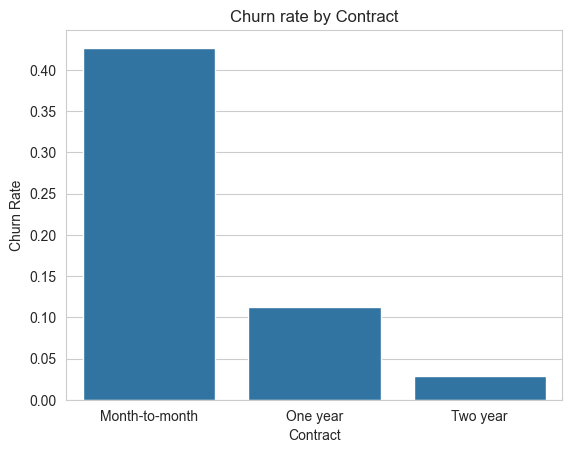

In [35]:
sns.barplot(
    x = churn_analysis("Contract").index,
    y = churn_analysis("Contract").values,
)

plt.title("Churn rate by Contract")
plt.ylabel("Churn Rate")
plt.show()

In [37]:
df.groupby(["Contract", "InternetService"])["Churn"].mean()

Contract        InternetService
Month-to-month  DSL                0.322159
                Fiber optic        0.546053
                No                 0.188931
One year        DSL                0.092982
                Fiber optic        0.192950
                No                 0.024725
Two year        DSL                0.019108
                Fiber optic        0.072261
                No                 0.007837
Name: Churn, dtype: float64

In [38]:
df.groupby(["Contract", "TechSupport"])["Churn"].mean()

Contract        TechSupport        
Month-to-month  No                     0.503731
                No internet service    0.188931
                Yes                    0.307004
One year        No                     0.147217
                No internet service    0.024725
                Yes                    0.135870
Two year        No                     0.059322
                No internet service    0.007837
                Yes                    0.035323
Name: Churn, dtype: float64

In [39]:
import itertools
cols = ["Contract", "InternetService", "TechSupport", "Partner", "Dependents"]

for combo in itertools.combinations(cols, 2):
   print("\n", combo)
   print(df.groupby(list(combo))["Churn"].mean().sort_values(ascending=False).head())


 ('Contract', 'InternetService')
Contract        InternetService
Month-to-month  Fiber optic        0.546053
                DSL                0.322159
One year        Fiber optic        0.192950
Month-to-month  No                 0.188931
One year        DSL                0.092982
Name: Churn, dtype: float64

 ('Contract', 'TechSupport')
Contract        TechSupport        
Month-to-month  No                     0.503731
                Yes                    0.307004
                No internet service    0.188931
One year        No                     0.147217
                Yes                    0.135870
Name: Churn, dtype: float64

 ('Contract', 'Partner')
Contract        Partner
Month-to-month  No         0.446894
                Yes        0.391304
One year        Yes        0.118072
                No         0.105754
Two year        No         0.033797
Name: Churn, dtype: float64

 ('Contract', 'Dependents')
Contract        Dependents
Month-to-month  No            0.452366

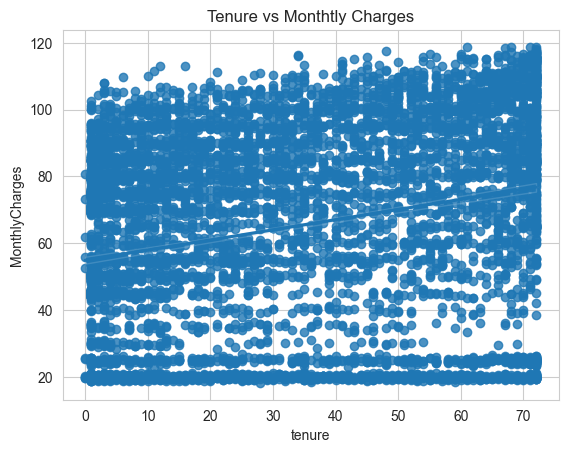

In [40]:
sns.regplot(x="tenure", y="MonthlyCharges", data=df )
plt.title("Tenure vs Monthtly Charges")
plt.show()


In [41]:
x = df[["tenure", "MonthlyCharges"]]
y = df['Churn']

model = LinearRegression()
model.fit(x,y)
print("Coeficient:", model.coef_)

Coeficient: [-0.0076657   0.00438849]


In [43]:

importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": model.coef_[0]
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

NameError: name 'x_train' is not defined